# Exploratory Data Analysis — Wine Quality Dataset

Dataset: `Wine_Quality_Dataset.csv` — 4,898 white wine samples with 11 physicochemical properties and a `quality` score (3–9).

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [1]:
df = pd.read_csv('Wine_Quality_Dataset.csv')
df.head()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
0            7.0              0.27         0.36            20.7      0.045                 45.0                 170.0   1.0010  3.00       0.45      8.8        6
1            6.3              0.30         0.34             1.6      0.049                 14.0                 132.0   0.9940  3.30       0.49      9.5        6
2            8.1              0.28         0.40             6.9      0.050                 30.0                  97.0   0.9951  3.26       0.44     10.1        6
3            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0   0.9956  3.19       0.40      9.9        6
4            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0   0.9956  3.19       0.40      9.9        6

## 2. Basic Structure

In [1]:
df.shape

(4898, 12)

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [1]:
df.describe()

       fixed acidity  volatile acidity  citric acid  residual sugar    chlorides  free sulfur dioxide  total sulfur dioxide      density           pH    sulphates      alcohol      quality
count    4898.000000       4898.000000  4898.000000     4898.000000  4898.000000          4898.000000           4898.000000  4898.000000  4898.000000  4898.000000  4898.000000  4898.000000
mean        6.854788          0.278241     0.334192        6.391415     0.045772            35.308085            138.360657     0.994027     3.188267     0.489847    10.514267     5.877909
std         0.843868          0.100795     0.121020        5.072058     0.021848            17.007137             42.498065     0.002991     0.151001     0.114126     1.230621     0.885639
min         3.800000          0.080000     0.000000        0.600000     0.009000             2.000000              9.000000     0.987110     2.720000     0.220000     8.000000     3.000000
25%         6.300000          0.210000     0.270000    

## 3. Data Quality Checks

In [1]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0

In [1]:
df.duplicated().sum()

937

No missing values, but **937 duplicate rows** exist. These are dropped below.

In [1]:
df = df.drop_duplicates()
df.shape

(3961, 12)

## 4. Target Variable: `quality`

In [1]:
df['quality'].value_counts().sort_index()

quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5

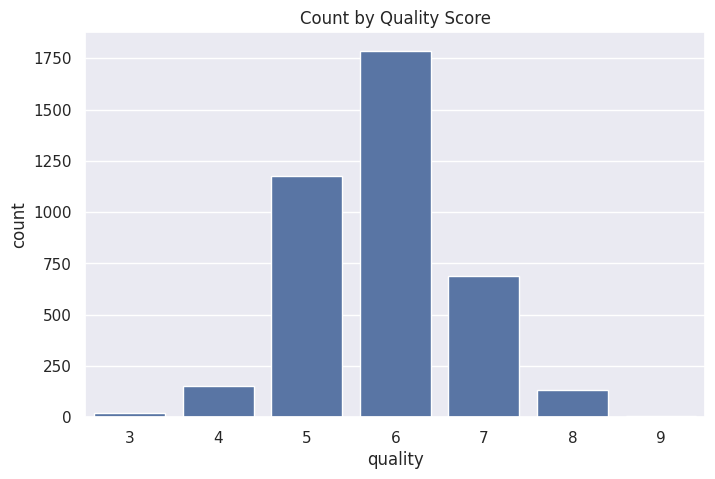

In [1]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title('Count by Quality Score')
plt.show()

The quality distribution is heavily concentrated around scores **5–7**, with very few wines rated at the extremes (3, 8, or 9) — a class imbalance worth keeping in mind for any modeling downstream.

## 5. Outlier Detection (IQR method)

In [1]:
feature_cols = [c for c in df.columns if c != 'quality']

In [1]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[feature_cols] < (Q1 - 1.5*IQR)) | (df[feature_cols] > (Q3 + 1.5*IQR))).any(axis=1)
df_no_outliers = df[~outlier_mask]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)
print("Outlier rows removed:", outlier_mask.sum())

Original shape: (3961, 12)
After removing outliers: (3255, 12)
Outlier rows removed: 706

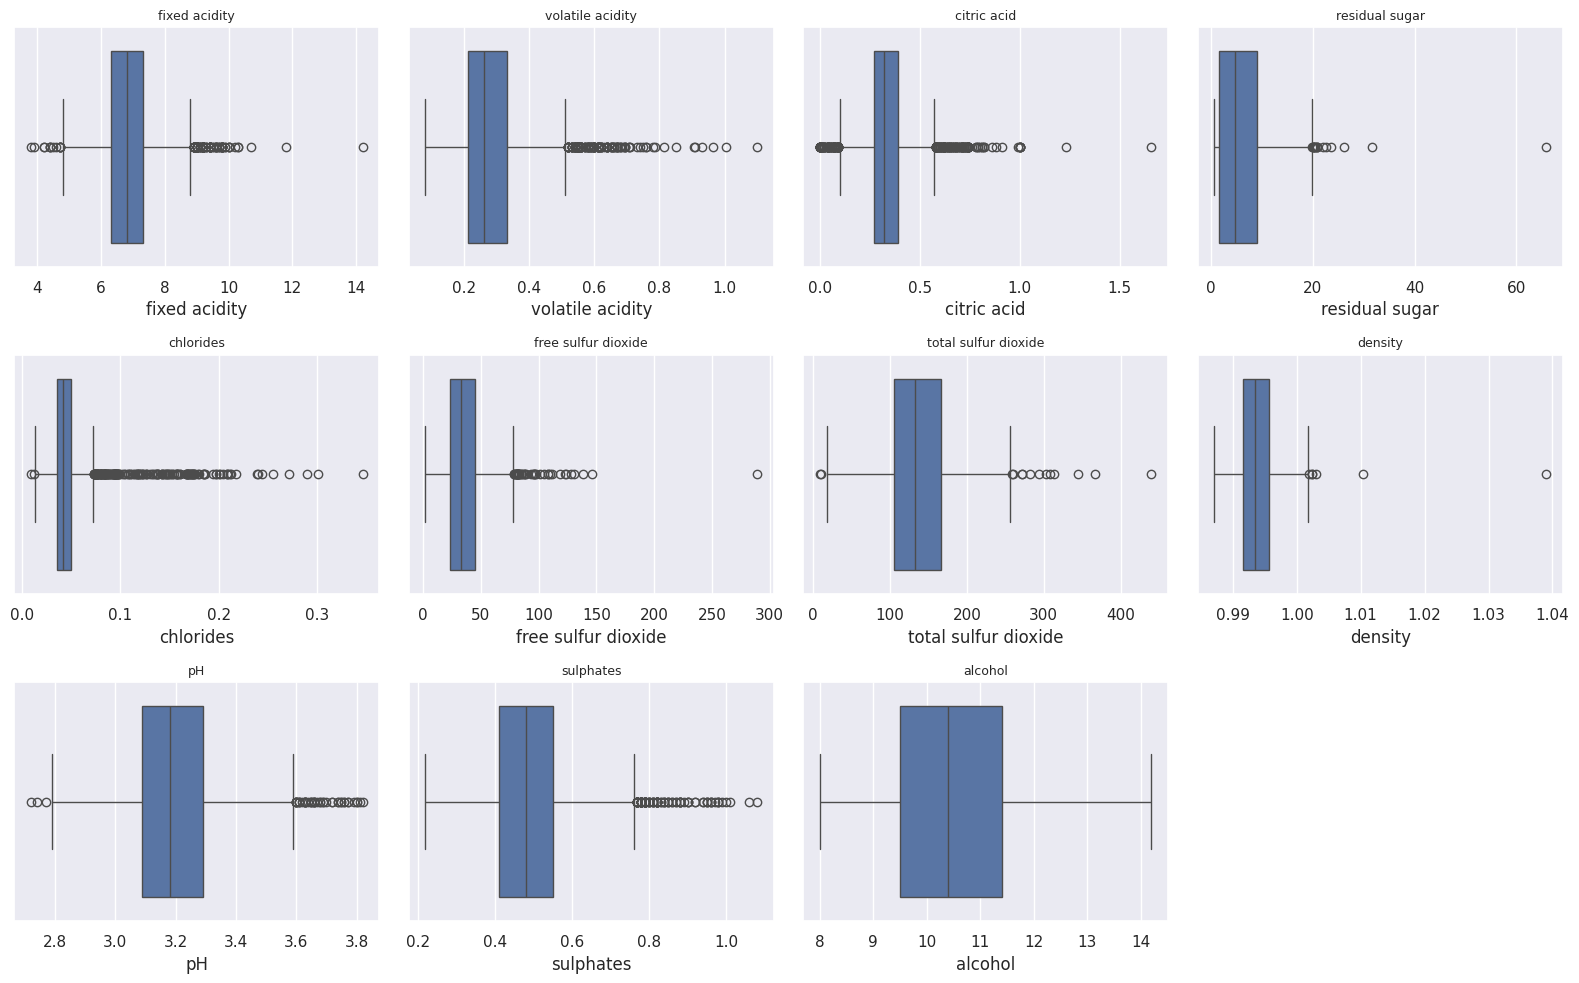

In [1]:
plt.figure(figsize=(16,10))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

`residual sugar`, `free sulfur dioxide`, and `total sulfur dioxide` show the most extreme outliers relative to their IQR.

## 6. Univariate Distributions

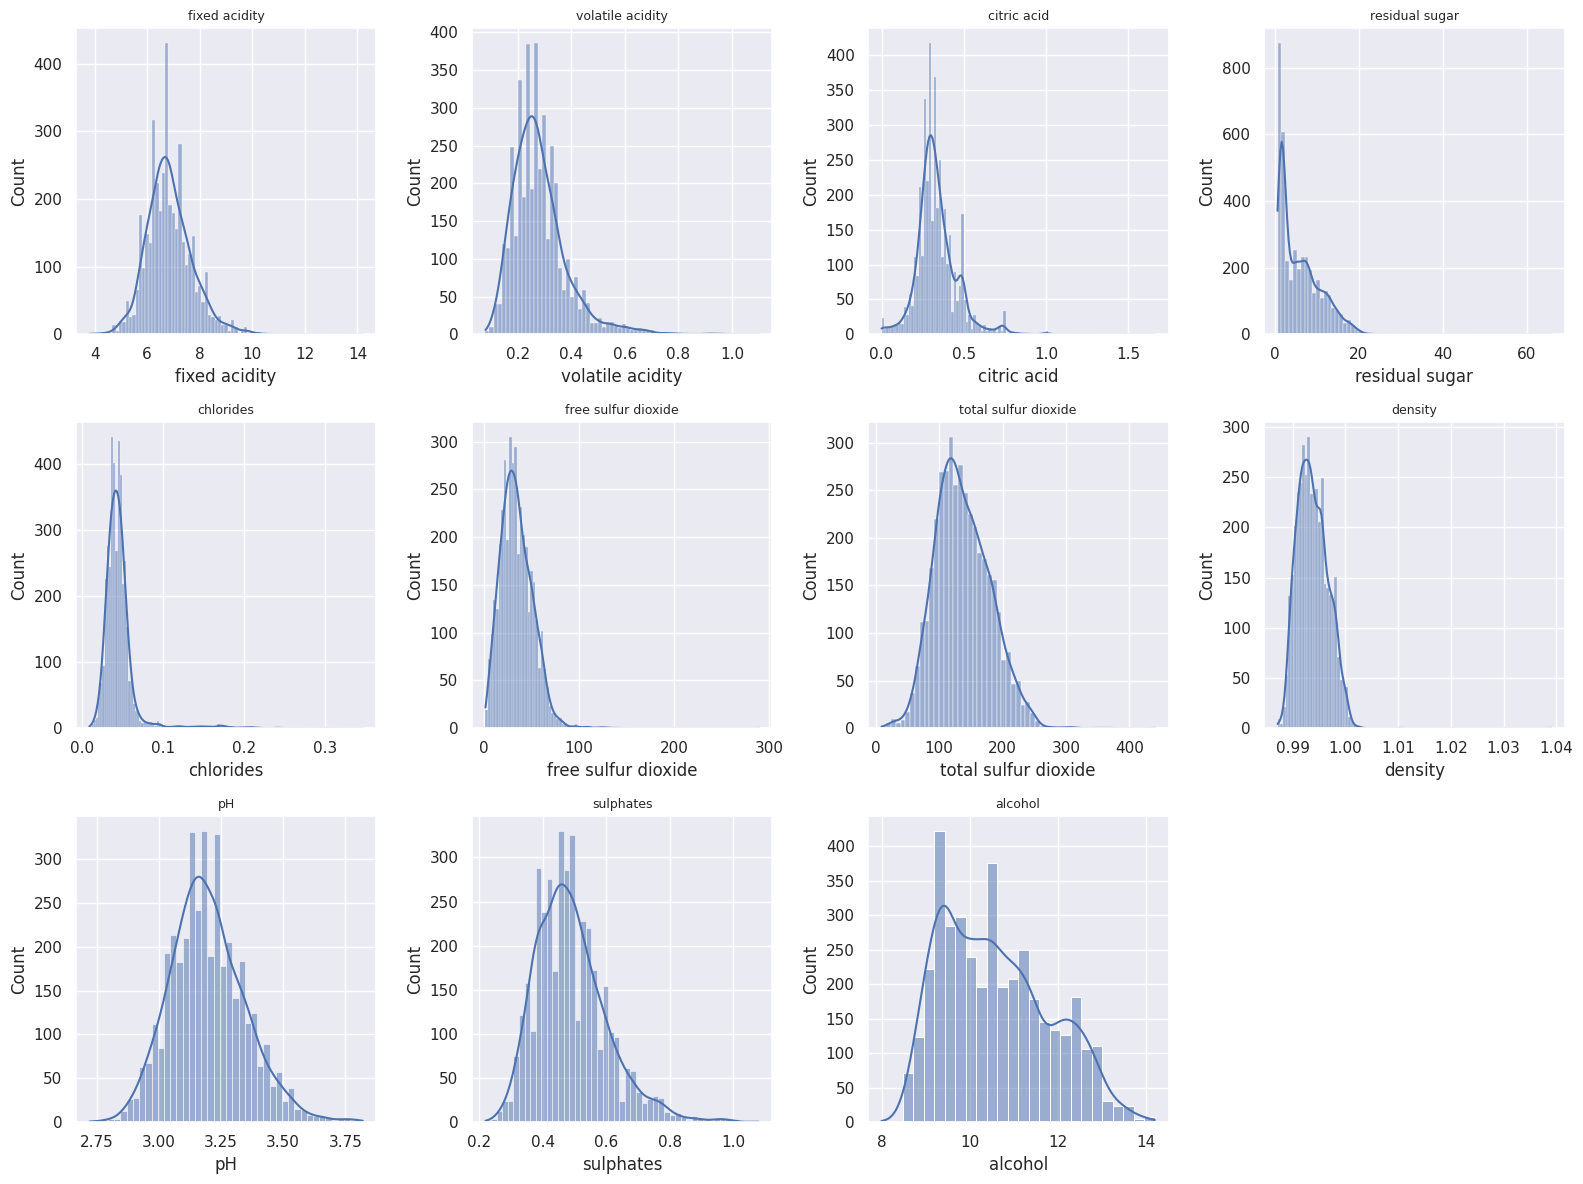

In [1]:
plt.figure(figsize=(16,12))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

In [1]:
corr = df.corr()
corr

                      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide   density        pH  sulphates   alcohol   quality
fixed acidity              1.000000         -0.019214     0.298959        0.083620   0.024036            -0.058396              0.082425  0.266091 -0.431274  -0.017453 -0.110788 -0.124636
volatile acidity          -0.019214          1.000000    -0.163228        0.098340   0.086287            -0.102471              0.102315  0.060603 -0.046954  -0.021150  0.046815 -0.190678
citric acid                0.298959         -0.163228     1.000000        0.106269   0.132590             0.091681              0.122845  0.160076 -0.183015   0.049442 -0.076514  0.007065
residual sugar             0.083620          0.098340     0.106269        1.000000   0.076091             0.306835              0.409583  0.820498 -0.165997  -0.020503 -0.398167 -0.117339
chlorides                  0.024036          0.086287     0.

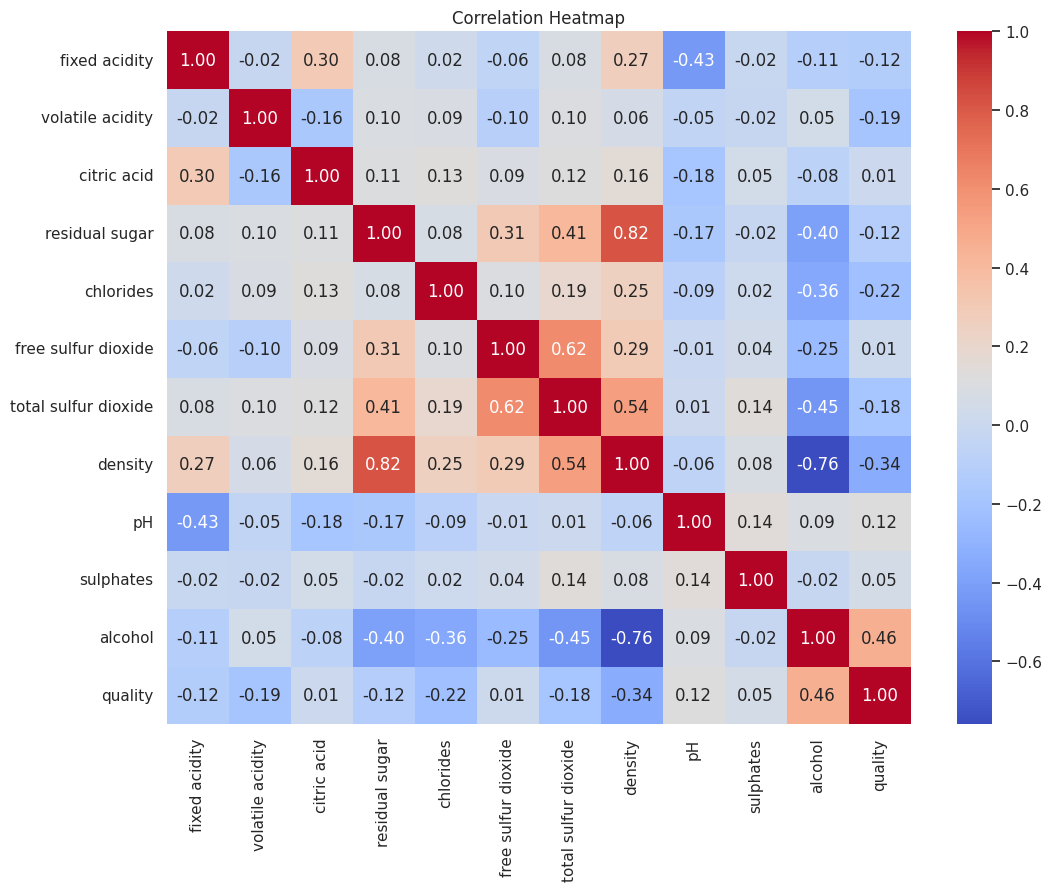

In [1]:
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [1]:
corr_quality = corr['quality'].drop('quality').sort_values(ascending=False)
corr_quality

alcohol                 0.462869
pH                      0.123829
sulphates               0.053200
free sulfur dioxide     0.010507
citric acid             0.007065
residual sugar         -0.117339
fixed acidity          -0.124636
total sulfur dioxide   -0.183356
volatile acidity       -0.190678
chlorides              -0.217739
density                -0.337805

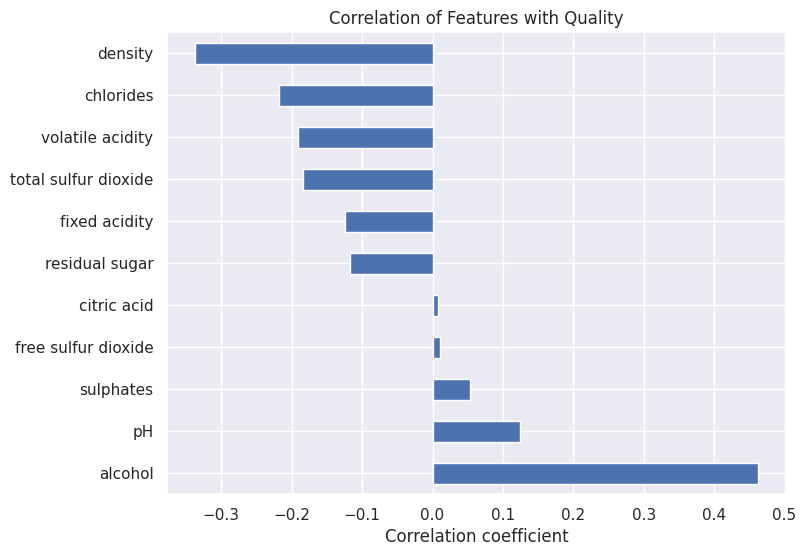

In [1]:
plt.figure(figsize=(8,6))
corr_quality.plot(kind='barh')
plt.title('Correlation of Features with Quality')
plt.xlabel('Correlation coefficient')
plt.show()

**`alcohol`** has the strongest positive correlation with quality, while **`density`** and **`chlorides`** are the strongest negative correlates.

## 8. Bivariate Analysis

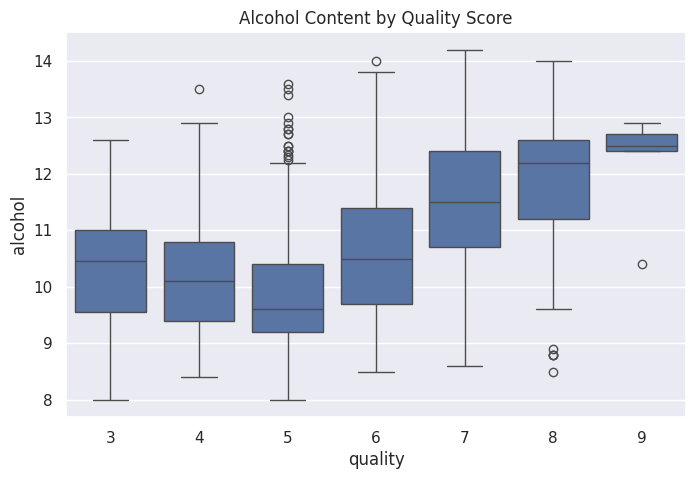

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol Content by Quality Score')
plt.show()

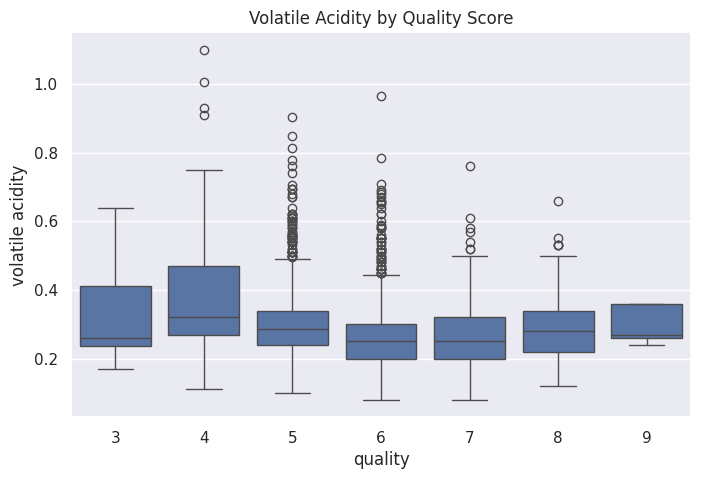

In [1]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity by Quality Score')
plt.show()

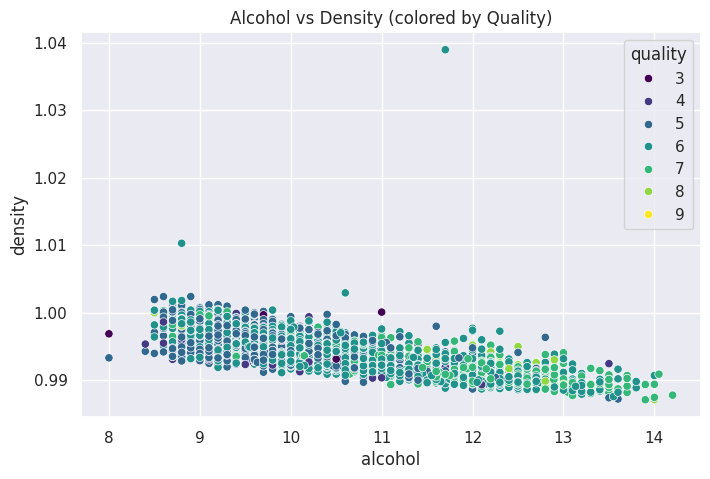

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='alcohol', y='density', hue='quality', data=df, palette='viridis')
plt.title('Alcohol vs Density (colored by Quality)')
plt.show()

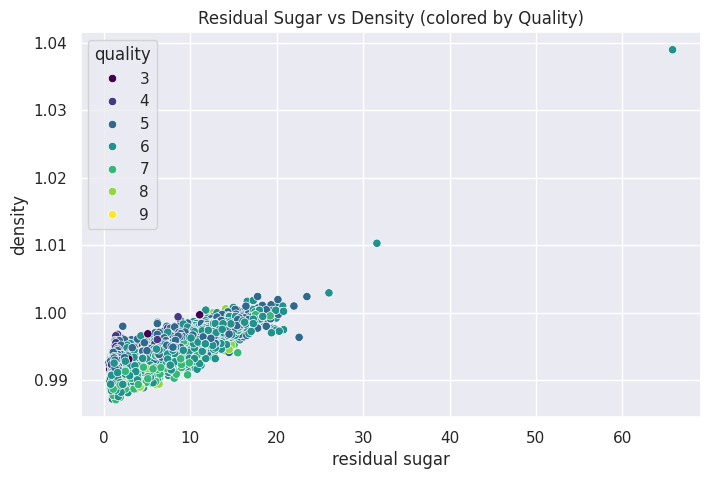

In [1]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='residual sugar', y='density', hue='quality', data=df, palette='viridis')
plt.title('Residual Sugar vs Density (colored by Quality)')
plt.show()

## 9. Summary

- **4,898 samples, 12 columns** (11 chemical features + `quality`); no missing values, but **937 duplicate rows** were found and removed.
- `quality` is imbalanced — most wines score **5, 6, or 7**; very few score 3, 8, or 9.
- IQR-based outlier detection flags a modest number of rows, concentrated in `residual sugar` and the sulfur dioxide columns.
- **`alcohol`** is the feature most positively correlated with `quality`; **`density`** and **`volatile acidity`** are the strongest negative correlates — consistent with the general winemaking intuition that higher alcohol and lower volatile acidity tend to signal better-rated wine.